# Ćw.7d Przewidywanie ruchu kwadratu/Moving Square Video Prediction



Jednym z zastosowań łączenia CNN i LSTM w celu klasyfikacji szeregów czasowych jest użycie CNN do wyodrębnienia cech z danych szeregów czasowych, a następnie przekazanie tych cech do LSTM w celu klasyfikacji. Pozwala to CNN na uchwycenie lokalnych wzorców w danych, podczas gdy LSTM może nauczyć się zależności czasowych i dokonać ostatecznego przewidywania.

 Problem przewidywania ruchomego kwadratu wideo analizujemy w celu zademonstrowania łącznego działania sieci CNN i LSTM.
Problem polega na wygenerowaniu sekwencji klatek. Na każdym obrazie rysowana jest linia od lewej do prawej lub od prawej do lewej. Każda klatka pokazuje przedłużenie linii o jeden piksel. Zadaniem modelu jest sklasyfikowanie, czy linia przesunęła się w lewo czy w prawo w sekwencji klatek. Technicznie rzecz biorąc, problem ten jest problemem klasyfikacji sekwencji w ramach modelu predykcji wiele-do-jednego.

Jest to  przykład z książki Jasona Brownlee [Long Short Term Memory Networks with Python](https://machinelearningmastery.com/lstms-with-python/). Przykład ilustruje użycie CNN i LSTM, tj. LSTM z danymi wejściowymi z CNN. W książce autor korzysta z biblioteki Keras.


In [2]:
from __future__ import division, print_function
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
%matplotlib inline

In [3]:
import os

# Utwórz katalog danych, jeśli nie istnieje.
DATA_DIR = "/content/sample_data"
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

MODEL_FILE = os.path.join(DATA_DIR, "CW7-{:d}.model")


TRAINING_SIZE = 5000
VALIDATION_SIZE = 100
TEST_SIZE = 500

SEQUENCE_LENGTH = 50
FRAME_SIZE = 50

BATCH_SIZE = 32

NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

## Przygotowanie danych

Nasze dane będą partiami sekwencji obrazów. Każdy obraz będzie musiał być w formacie channel-first, ponieważ Pytorch preferuje układ [B, C, H, W] (TensorFlow-[B, H, W, C]). Nasze dane wyjściowe będą więc w formacie (batch_size, sequence_length, num_channels, height, width).
Poniższy kod tworzy prostą animację kwadratu poruszającego się po klatce, dostarczając danych wizualnych, które można wykorzystać do trenowania modelu w celu przewidywania kierunku ruchu.

Wypróbuj poniższy kod kilka razy.



1. frame: Bieżąca klatka (tablica NumPy).
2. x: Bieżąca współrzędna x kwadratu.
3. y: Bieżąca współrzędna y kwadratu.
4. move_right: Wartość logiczna wskazująca kierunek ruchu (1 dla ruchu w prawo, 0 dla ruchu w lewo).
5. upd_int: Wartość całkowita do aktualizacji piksela reprezentującego kwadrat w nowej klatce
    (0 aby utworzyć czarny kwadrat na białym tle)
    

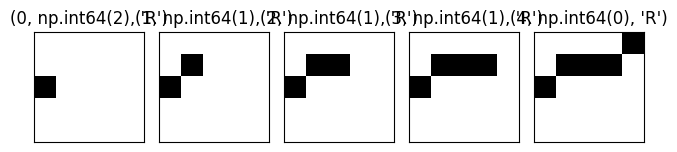

In [4]:
#Funkcja tworzy następną klatkę w sekwencji, przesuwając kwadrat o jeden krok w prawo lub w lewo.
def next_frame(frame, x, y, move_right, upd_int):
    frame_size = frame.shape[0]

    if x is None and y is None:#pierwsza klatka, inicjalizacja początkowej klatki
        x = 0 if (move_right == 1) else (frame_size - 1)#Współrzędna x jest ustawiona na 0 dla ruchu w prawo i frame_size - 1 dla ruchu w lewo. Współrzędna y jest wybierana losowo w obrębie wysokości ramki.
        y = np.random.randint(0, frame_size, 1)[0]
    else:
        if y == 0:
            y = np.random.randint(y, y + 1, 1)[0]
        elif y == frame_size - 1:
            y = np.random.randint(y - 1, y, 1)[0]
        else:
            y = np.random.randint(y - 1, y + 1, 1)[0]
        if move_right:
            x = x + 1
        else:
            x = x - 1
    new_frame = frame.copy()
    new_frame[y, x] = upd_int
    return new_frame, x, y
"""
    row, col: Początkowo ustawione na None, wskazując, że pozycja początkowa kwadratu jest nieznana.
    frame: Tablica NumPy 5x5 wypełniona jedynkami, reprezentująca białe tło.
    move_right: Losowo przypisywana wartość 1 (w prawo) lub 0 (w lewo) w celu określenia kierunku ruchu kwadratu.
"""
row, col = None, None
frame = np.ones((5, 5))
move_right = 1 if np.random.random() < 0.5 else 0
for i in range(5):
    frame, col, row = next_frame(frame, col, row, move_right, 0)
    plt.subplot(1, 5, (i+1))
    plt.xticks([])
    plt.yticks([])
    plt.title((col, row, "R" if (move_right==1) else "L"))
    plt.imshow(frame, cmap="gray")
plt.tight_layout()
plt.show()

In [5]:
def generate_data(frame_size, sequence_length, num_samples):
    assert(frame_size == sequence_length)
    xs, ys = [], []
    for bid in range(num_samples):
        frame_seq = []
        row, col = None, None
        frame = np.ones((frame_size, frame_size))
        move_right = 1 if np.random.random() < 0.5 else 0
        for sid in range(sequence_length):
            frm, col, row = next_frame(frame, col, row, move_right, 0)
            frm = frm.reshape((1, frame_size, frame_size))
            frame_seq.append(frm)
        xs.append(np.array(frame_seq))
        ys.append(move_right)
    return np.array(xs), np.array(ys)

X, y = generate_data(FRAME_SIZE, SEQUENCE_LENGTH, 10)
print(X.shape, y.shape)

(10, 50, 1, 50, 50) (10,)


In [6]:
Xtrain, ytrain = generate_data(FRAME_SIZE, SEQUENCE_LENGTH, TRAINING_SIZE)
Xval, yval = generate_data(FRAME_SIZE, SEQUENCE_LENGTH, VALIDATION_SIZE)
Xtest, ytest = generate_data(FRAME_SIZE, SEQUENCE_LENGTH, TEST_SIZE)
print(Xtrain.shape, ytrain.shape, Xval.shape, yval.shape, Xtest.shape, ytest.shape)

(5000, 50, 1, 50, 50) (5000,) (100, 50, 1, 50, 50) (100,) (500, 50, 1, 50, 50) (500,)


## Definiowanie architektury sieci

Chcemy zbudować sieć CNN-LSTM. Każdy obraz w sekwencji będzie podawany do CNN, która nauczy się tworzyć wektor cech dla obrazu. Sekwencja wektorów zostanie przekazana do LSTM, a LSTM nauczy się generować wektor kontekstu, który zostanie następnie przekazany do warstwy, która będzie przewidywać, czy kwadrat porusza się w lewo czy w prawo.

In [7]:
class CNN(nn.Module):

    def __init__(self, input_height, input_width, input_channels,
                 output_channels,
                 conv_kernel_size, conv_stride, conv_padding,
                 pool_size):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, output_channels,
                               kernel_size=conv_kernel_size,
                               stride=conv_stride,
                               padding=conv_padding)
        self.relu1 = nn.ReLU()
        self.output_height = input_height // pool_size
        self.output_width = input_width // pool_size
        self.output_channels = output_channels
        self.pool_size = pool_size

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = F.max_pool2d(x, self.pool_size)
        x = x.view(x.size(0), self.output_channels * self.output_height * self.output_width)
        return x

cnn = CNN(FRAME_SIZE, FRAME_SIZE, 1, 2, 2, 1, 1, 2)
print(cnn)

# size debugging
print("--- size debugging ---")
inp = torch.randn(BATCH_SIZE, 1, FRAME_SIZE, FRAME_SIZE)
out = cnn(inp)
print(out.size())

CNN(
  (conv1): Conv2d(1, 2, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
)
--- size debugging ---
torch.Size([32, 1250])


In [8]:
class CNNLSTM(nn.Module):

    def __init__(self, image_size, input_channels, output_channels,
                 conv_kernel_size, conv_stride, conv_padding, pool_size,
                 seq_length, hidden_size, num_layers, output_size):
        super(CNNLSTM, self).__init__()
        # capture variables
        self.num_layers = num_layers
        self.seq_length = seq_length
        self.image_size = image_size
        self.output_channels = output_channels
        self.hidden_size = hidden_size
        self.lstm_input_size = output_channels * (image_size // pool_size) ** 2
        # define network layers
        self.cnn = CNN(image_size, image_size, input_channels, output_channels,
                       conv_kernel_size, conv_stride, conv_padding, pool_size)
        self.lstm = nn.LSTM(self.lstm_input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.Softmax()

    def forward(self, x):
        if torch.cuda.is_available():
            x = x.cuda()

        if torch.cuda.is_available():
            h0 = (Variable(torch.randn(self.num_layers, x.size(0), self.hidden_size).cuda()),
                  Variable(torch.randn(self.num_layers, x.size(0), self.hidden_size).cuda()))
        else:
            h0 = (Variable(torch.randn(self.num_layers, x.size(0), self.hidden_size)),
                  Variable(torch.randn(self.num_layers, x.size(0), self.hidden_size)))

        cnn_out = []
        for i in range(self.seq_length):
            cnn_out.append(self.cnn(x[:, i, :, :, :]))
        x = torch.cat(cnn_out, dim=1).view(-1, self.seq_length, self.lstm_input_size)
        x, h0 = self.lstm(x, h0)
        x = self.fc(x[:, -1, :])
        x = self.softmax(x)
        return x

model = CNNLSTM(FRAME_SIZE, 1, 2, 2, 1, 1, 2, SEQUENCE_LENGTH, 50, 1, 2)
if torch.cuda.is_available():
    model.cuda()
print(model)

# size debugging
print("--- size debugging ---")
inp = torch.randn(BATCH_SIZE, SEQUENCE_LENGTH, 1, FRAME_SIZE, FRAME_SIZE)
out = model(inp)
print(out.size())

CNNLSTM(
  (cnn): CNN(
    (conv1): Conv2d(1, 2, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (relu1): ReLU()
  )
  (lstm): LSTM(1250, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=2, bias=True)
  (softmax): Softmax(dim=None)
)
--- size debugging ---
torch.Size([32, 2])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Uczenie sieci

Uczenie na GPU jest preferowany dla tego przykładu, bo na CPU zajmuje dużo czasu. Podczas niektórych przebiegów dokładność uczenia i walidacji utknęła, prawdopodobnie z powodu złej inicjalizacji, poprawką wydaje się być po prostu ponawianie uczenia, aż do uzyskania dobrej dokładności uczenia i walidacji i użycie wynikowego modelu.

In [10]:
def compute_accuracy(pred_var, true_var):
    if torch.cuda.is_available():
        ypred = pred_var.cpu().data.numpy()
        ytrue = true_var.cpu().data.numpy()
    else:
        ypred = pred_var.data.numpy()
        ytrue = true_var.data.numpy()
    return accuracy_score(ypred, ytrue)

history = []
for epoch in range(NUM_EPOCHS):
    num_batches = Xtrain.shape[0] // BATCH_SIZE

    shuffled_indices = np.random.permutation(np.arange(Xtrain.shape[0]))
    train_loss, train_acc = 0., 0.
    for bid in range(num_batches):
        Xbatch_data = Xtrain[shuffled_indices[bid * BATCH_SIZE : (bid+1) * BATCH_SIZE]]
        ybatch_data = ytrain[shuffled_indices[bid * BATCH_SIZE : (bid+1) * BATCH_SIZE]]
        Xbatch = Variable(torch.from_numpy(Xbatch_data).float())
        ybatch = Variable(torch.from_numpy(ybatch_data).long())
        if torch.cuda.is_available():
            Xbatch = Xbatch.cuda()
            ybatch = ybatch.cuda()

        # zerowanie gradientów
        optimizer.zero_grad()

        # propagacja w przód
        Ybatch_ = model(Xbatch)
        loss = loss_fn(Ybatch_, ybatch)

        # propagacja wsteczna
        loss.backward()

        train_loss += loss.item()

        _, ybatch_ = Ybatch_.max(1)
        train_acc += compute_accuracy(ybatch_, ybatch)

        optimizer.step()

    # Strata uczenia i accuracy
    train_loss /= num_batches
    train_acc /= num_batches

    # compute validation loss and accuracy
    val_loss, val_acc = 0., 0.
    num_val_batches = Xval.shape[0] // BATCH_SIZE
    for bid in range(num_val_batches):
        # data
        Xbatch_data = Xval[bid * BATCH_SIZE : (bid + 1) * BATCH_SIZE]
        ybatch_data = yval[bid * BATCH_SIZE : (bid + 1) * BATCH_SIZE]
        Xbatch = Variable(torch.from_numpy(Xbatch_data).float())
        ybatch = Variable(torch.from_numpy(ybatch_data).long())
        if torch.cuda.is_available():
            Xbatch = Xbatch.cuda()
            ybatch = ybatch.cuda()

        Ybatch_ = model(Xbatch)
        loss = loss_fn(Ybatch_, ybatch)
        val_loss += loss.item()

        _, ybatch_ = Ybatch_.max(1)
        val_acc += compute_accuracy(ybatch_, ybatch)

    val_loss /= num_val_batches
    val_acc /= num_val_batches

    torch.save(model.state_dict(), MODEL_FILE.format(epoch+1))
    print("Epoch {:2d}/{:d}: loss={:.3f}, acc={:.3f}, val_loss={:.3f}, val_acc={:.3f}"
          .format((epoch+1), NUM_EPOCHS, train_loss, train_acc, val_loss, val_acc))

    history.append((train_loss, val_loss, train_acc, val_acc))

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules

Epoch  1/5: loss=0.487, acc=0.815, val_loss=0.315, val_acc=1.000


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules

Epoch  2/5: loss=0.324, acc=0.994, val_loss=0.315, val_acc=1.000


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules

Epoch  3/5: loss=0.314, acc=1.000, val_loss=0.314, val_acc=1.000


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules

Epoch  4/5: loss=0.314, acc=1.000, val_loss=0.314, val_acc=1.000


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules

Epoch  5/5: loss=0.314, acc=1.000, val_loss=0.314, val_acc=1.000


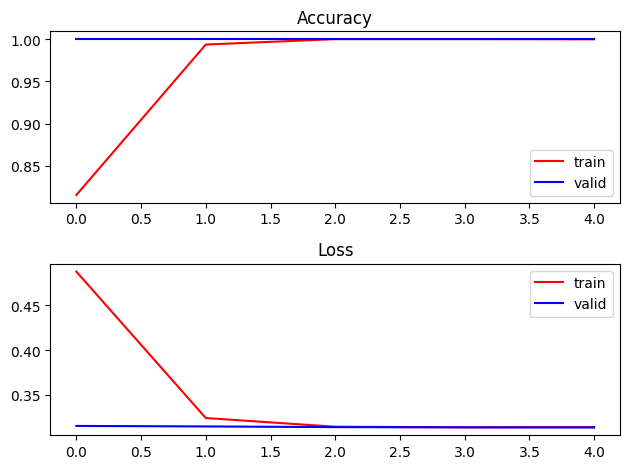

In [11]:
losses = [x[0] for x in history]
val_losses = [x[1] for x in history]
accs = [x[2] for x in history]
val_accs = [x[3] for x in history]

plt.subplot(211)
plt.title("Accuracy")
plt.plot(accs, color="r", label="train")
plt.plot(val_accs, color="b", label="valid")
plt.legend(loc="best")

plt.subplot(212)
plt.title("Loss")
plt.plot(losses, color="r", label="train")
plt.plot(val_losses, color="b", label="valid")
plt.legend(loc="best")

plt.tight_layout()
plt.show()

## Testowanie

In [12]:
saved_model = CNNLSTM(FRAME_SIZE, 1, 2, 2, 1, 1, 2, SEQUENCE_LENGTH, 50, 1, 2)
saved_model.load_state_dict(torch.load(MODEL_FILE.format(5)))
if torch.cuda.is_available():
    saved_model.cuda()

In [13]:
ylabels, ypreds = [], []
num_test_batches = Xtest.shape[0] // BATCH_SIZE
for bid in range(num_test_batches):
    Xbatch_data = Xtest[bid * BATCH_SIZE : (bid + 1) * BATCH_SIZE]
    ybatch_data = ytest[bid * BATCH_SIZE : (bid + 1) * BATCH_SIZE]
    Xbatch = Variable(torch.from_numpy(Xbatch_data).float())
    ybatch = Variable(torch.from_numpy(ybatch_data).long())
    if torch.cuda.is_available():
        Xbatch = Xbatch.cuda()
        ybatch = ybatch.cuda()

    Ybatch_ = saved_model(Xbatch)
    _, ybatch_ = Ybatch_.max(1)
    if torch.cuda.is_available():
        ylabels.extend(ybatch.cpu().data.numpy())
        ypreds.extend(ybatch_.cpu().data.numpy())
    else:
        ylabels.extend(ybatch.data.numpy())
        ypreds.extend(ybatch_.data.numpy())

print("Test accuracy: {:.3f}".format(accuracy_score(ylabels, ypreds)))
print("Confusion matrix")
print(confusion_matrix(ylabels, ypreds))

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Test accuracy: 1.000
Confusion matrix
[[246   0]
 [  0 234]]


In [14]:
for i in range(NUM_EPOCHS):
    os.remove(MODEL_FILE.format(i + 1))

Pętla iteruje przez zapisane pliki modeli i usuwa je jeden po drugim. Jest to często wykonywane w celu uniknięcia bałaganu i zaoszczędzenia miejsca w pamięci, gdy modele nie są już potrzebne.